### Importing library

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [10]:
data=pd.read_csv("london_merged.csv")

In [14]:
data.timestamp.apply(type).value_counts()

timestamp
<class 'str'>    17414
Name: count, dtype: int64

In [18]:
data['timestamp']=pd.to_datetime(data.timestamp)

In [22]:
data['date']=data.timestamp.dt.date

<Axes: xlabel='date'>

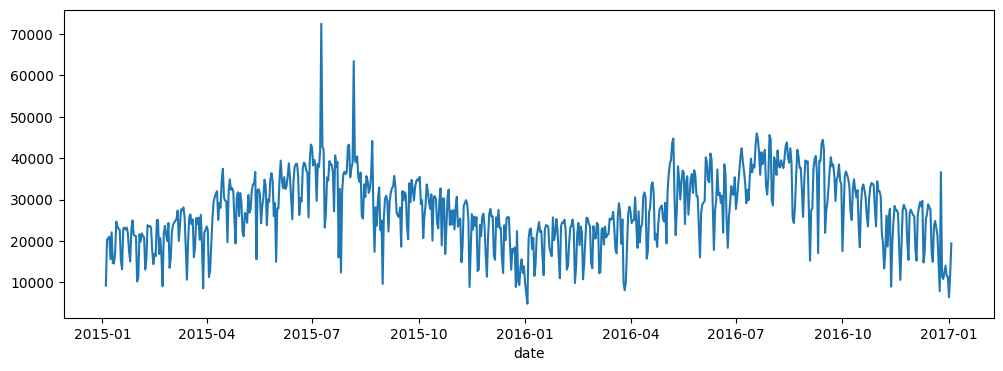

In [30]:
data.groupby('date')['cnt'].sum().plot(figsize=(12,4))

In [32]:
# motnh wise
data['month']=data.timestamp.dt.month

<Axes: xlabel='month'>

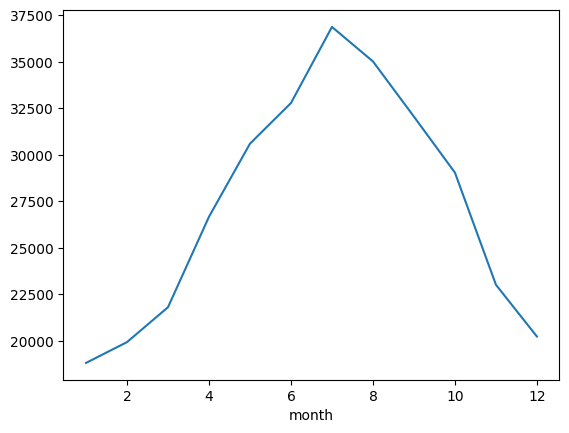

In [44]:
data.groupby(['month','date'])['cnt'].sum().groupby('month').mean().plot()

In [46]:
data.season.value_counts()

season
0.0    4394
1.0    4387
3.0    4330
2.0    4303
Name: count, dtype: int64

In [48]:
# dayof week
data['dayofweek']=data.timestamp.dt.day_of_week

<Axes: xlabel='dayofweek'>

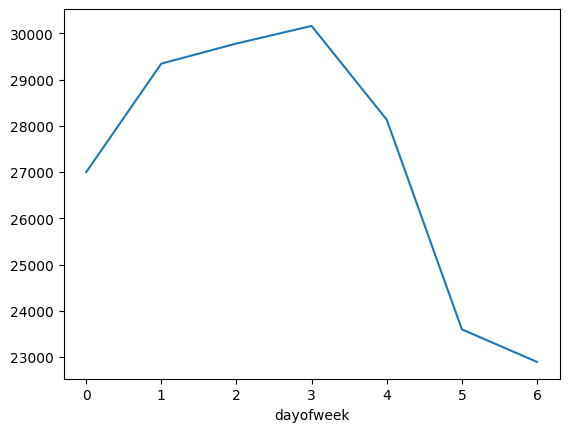

In [50]:
data.groupby(['dayofweek','date'])['cnt'].sum().groupby('dayofweek').mean().plot()

In [54]:
data['isweekend']=np.where(data.dayofweek.isin([5,6]),1,0)

In [60]:
data.groupby(['is_weekend', 'isweekend']).size()

is_weekend  isweekend
0.0         0            12444
1.0         1             4970
dtype: int64

In [66]:
data['hour']=data.timestamp.dt.hour

<Axes: xlabel='hour'>

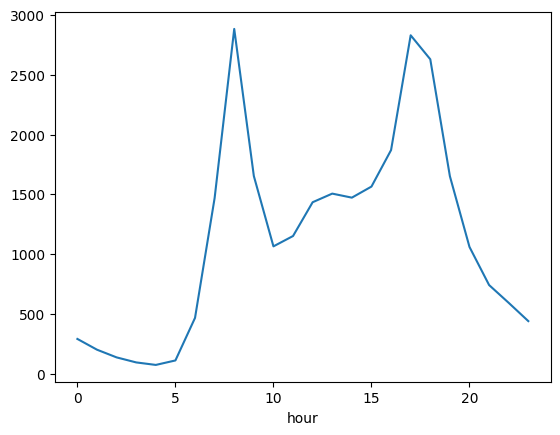

In [70]:
data.groupby("hour")['cnt'].mean().plot()

In [72]:
peak_hours=[7,8,9,16,17,18]

In [74]:
data['isPeakHour']=np.where(data.hour.isin(peak_hours),1,0)

In [78]:
data.groupby(['is_holiday','date'])['cnt'].sum()

is_holiday  date      
0.0         2015-01-04     9234
            2015-01-05    20372
            2015-01-06    20613
            2015-01-07    21064
            2015-01-08    15601
                          ...  
1.0         2016-05-30    23697
            2016-08-29    34176
            2016-12-26    11455
            2016-12-27    10842
            2017-01-02    11823
Name: cnt, Length: 730, dtype: int64